In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/ethiopia.csv",low_memory=False
)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [3]:
# Add new columns
df["Country"]="Ethiopia"
df["Date"]= pd.to_datetime(df["YEAR"]* 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [4]:
df= df.replace(-999, np.nan)
df.duplicated().sum()

np.int64(0)

No duplicated row was found

In [5]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

No missing value was found

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


Summary statistics reveal moderate temperatures, seasonal rainfall patterns, and significant diurnal temperature variation, all consistent with Ethiopia’s highland climate profile

In [8]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore, nan_policy='omit')

outliers = (np.abs(z_scores) > 3)

outlier_count = outliers.sum()

outlier_count

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

In [ ]:

df_cleaned = df.copy()

df_cleaned[col] = df_cleaned[col].clip(
    lower=df_cleaned[col].quantile(0.01),
    upper=df_cleaned[col].quantile(0.99)
)
df_cleaned.to_csv("../data/ethiopia_clean.csv", index=False)

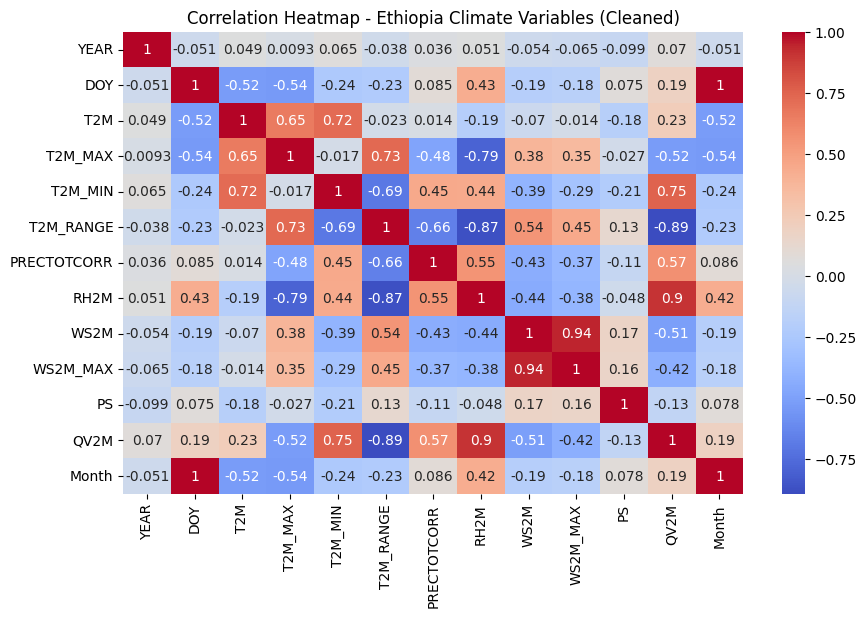

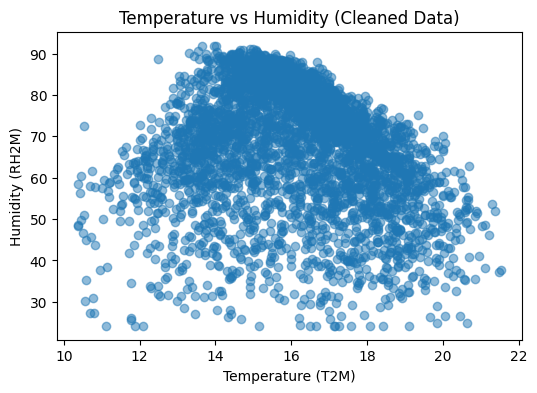

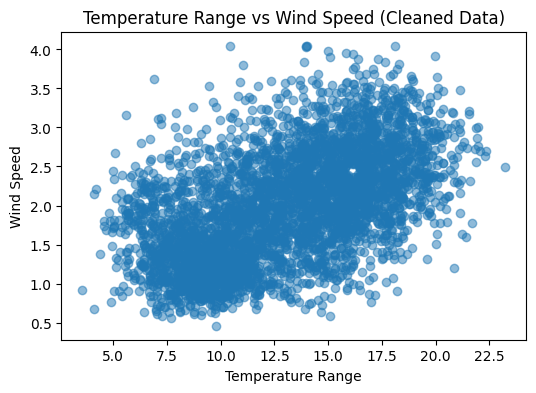

In [46]:


# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap (CLEANED DATA)
plt.figure(figsize=(10,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Ethiopia Climate Variables (Cleaned)")
plt.show()

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M"], df_cleaned["RH2M"], alpha=0.5)
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity (Cleaned Data)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M_RANGE"], df_cleaned["WS2M"], alpha=0.5)
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed (Cleaned Data)")
plt.show()

In [48]:
df_cleaned["PRECTOTCORR"].describe()

count    4108.000000
mean        3.440719
std         5.374903
min         0.000000
25%         0.020000
50%         0.820000
75%         4.580000
max        22.500978
Name: PRECTOTCORR, dtype: float64

The precipitation variable (PRECTOTCORR) exhibits a strongly right-skewed distribution. The median value (0.82) is significantly lower than the mean (3.44), indicating that most days experience low rainfall. However, the presence of a high maximum value (22.5) suggests occasional extreme rainfall events. Additionally, the large standard deviation (5.37) reflects high variability in precipitation patterns over time, with many near-zero values and a few extreme outliers influencing the distribution.

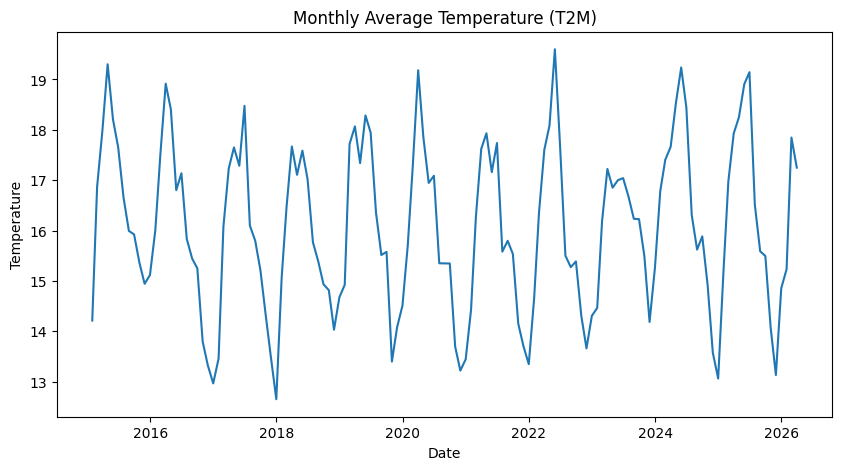

In [50]:
#T2m
import matplotlib.pyplot as plt

# ensure datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# set index for resampling
df_ts = df_cleaned.set_index("Date")

# monthly average temperature
monthly_temp = df_ts["T2M"].resample("ME").mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

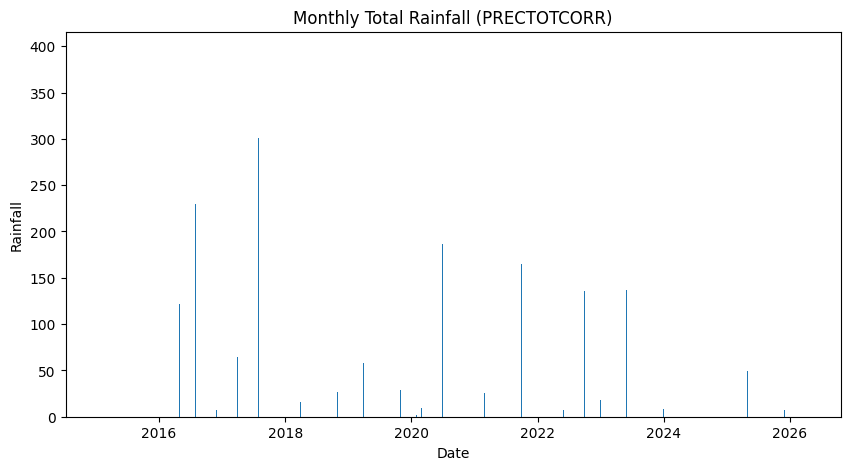

In [52]:
# Rain fall
monthly_rain = df_ts["PRECTOTCORR"].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Total Rainfall (PRECTOTCORR)")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.show()

In [53]:
# cleaned correlation
corr = df_cleaned.corr(numeric_only=True)

# unstack and sort correlations
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top Correlations:")
print(corr_pairs.head(10))

Top Correlations:
Month      DOY          0.996557
DOY        Month        0.996557
WS2M_MAX   WS2M         0.940930
WS2M       WS2M_MAX     0.940930
QV2M       RH2M         0.904850
RH2M       QV2M         0.904850
T2M_MIN    QV2M         0.753194
QV2M       T2M_MIN      0.753194
T2M_RANGE  T2M_MAX      0.731151
T2M_MAX    T2M_RANGE    0.731151
dtype: float64


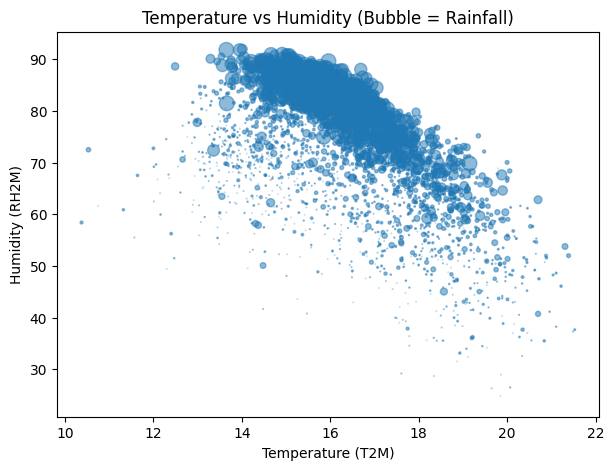

In [54]:
# bubble
plt.figure(figsize=(7,5))

plt.scatter(
    df_cleaned["T2M"],
    df_cleaned["RH2M"],
    s=df_cleaned["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()